# <p><u><center> Machine Learning Assigment </center></u></p>

## Dataset Information

1. **The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other.**<br>

2. **The iris data are a data frame of 150 measurements of iris petal and sepal lengths and widths, with 50 measurements for each species of “setosa,” “versicolor,” and “virginica.” Let us assume that we are doing some computation on the sepal length.**

**Attribute Information:**

1. sepal length in cm
2. sepal width in cm
3. petal length in cm
4. petal width in cm
5. class:<br>
   i. Iris Setosa<br>
   ii. Iris Versicolour<br>
   iii. Iris Virginica

## Import modules

In [20]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## <u> Loading the dataset </u>

In [21]:
df = pd.read_csv('/Users/skmirajulislam/Documents/MyPython/ML/Topstack/data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**To basic info about datatype**

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


**To display statistical details about data**

In [23]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**To display no. of samples on each class**

In [24]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## <u> Preprocessing the dataset </u>

**check for null values**

In [25]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [26]:
print('Any Missing value : ',df.isnull().values.any())

Any Missing value :  False


**Removing unusual coloumn**

In [27]:
df = df.drop(columns = ['Id'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Number of missing point :**

<Axes: >

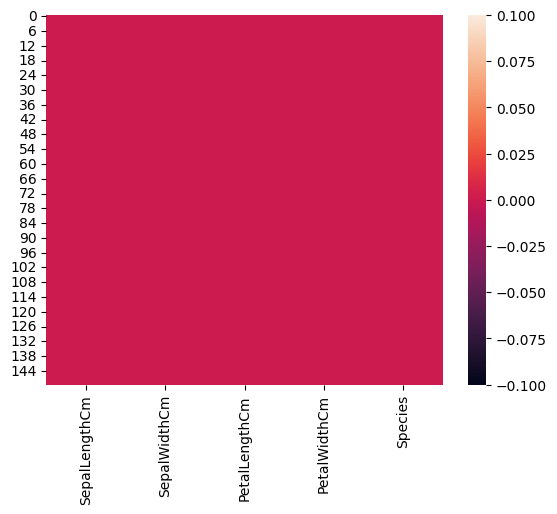

In [28]:
sns.heatmap(df.isnull())

## <u> Exploratory Data Analysis </u>

**Visualize the distribution of sepal lengths in your dataset**

Text(0, 0.5, 'Frequency')

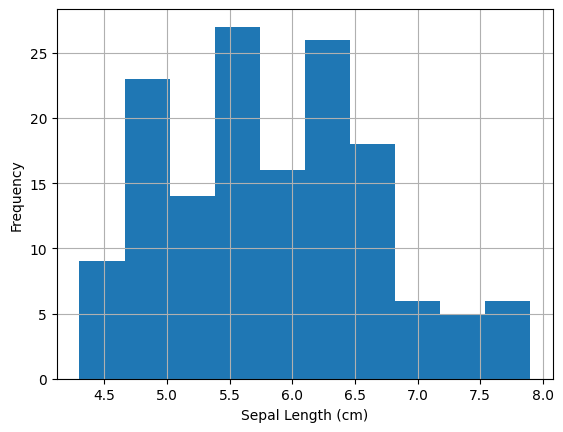

In [29]:
df['SepalLengthCm'].hist()
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')

**Visualize the distribution of sepal Width in your dataset**

Text(0, 0.5, 'Frequency')

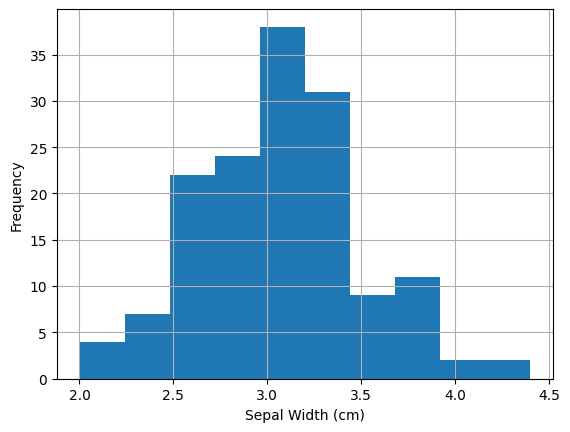

In [30]:
df['SepalWidthCm'].hist()
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')

**Visualize the distribution of Petal Length in your dataset**

Text(0, 0.5, 'Frequency')

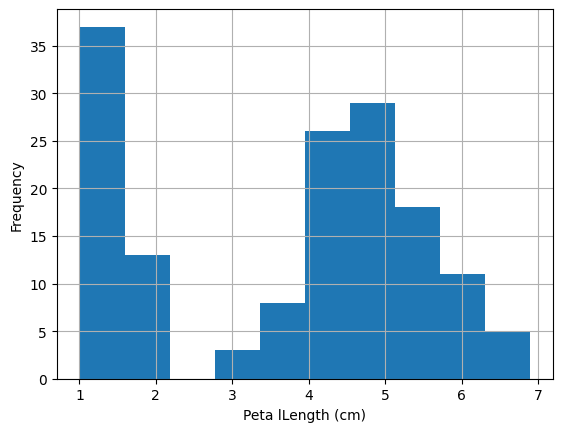

In [31]:
df['PetalLengthCm'].hist()
plt.xlabel('Peta lLength (cm)')
plt.ylabel('Frequency')

**Visualize the distribution of Petal width in your dataset**

Text(0, 0.5, 'Frequency')

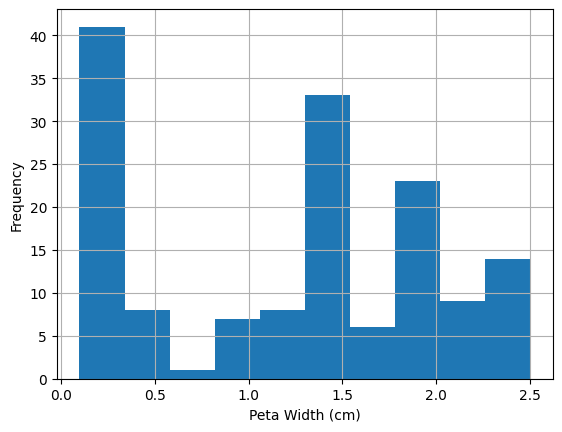

In [32]:
df['PetalWidthCm'].hist()
plt.xlabel('Peta Width (cm)')
plt.ylabel('Frequency')

**Relationships between variables and how they might be related to the species.**

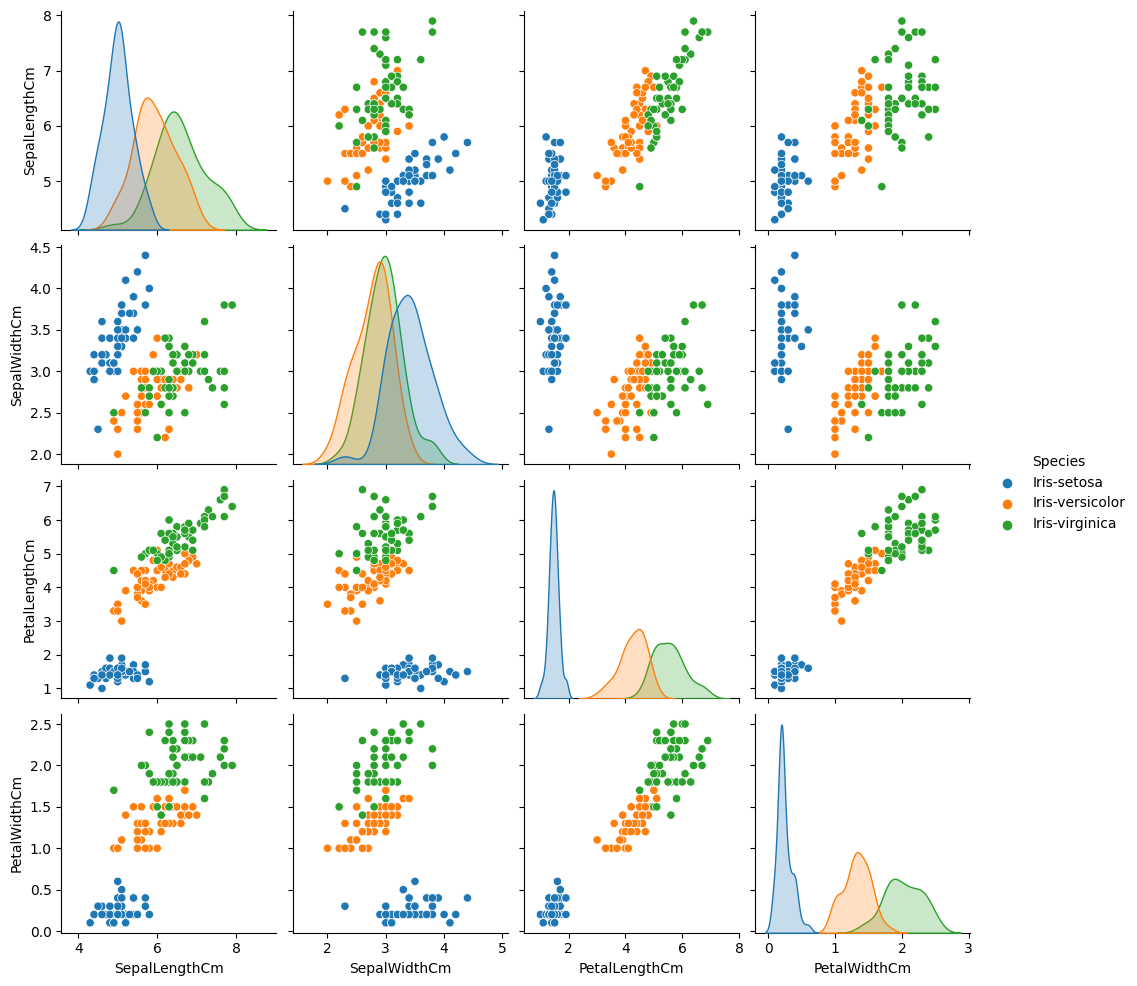

In [33]:
sns.pairplot(df,hue ='Species')

**It seems to create a scatter plot to visualize the relationship between sepal length and sepal width for different species of flowers in a DataFrame**

In [34]:
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica','Iris-versicolor','Iris-setosa']

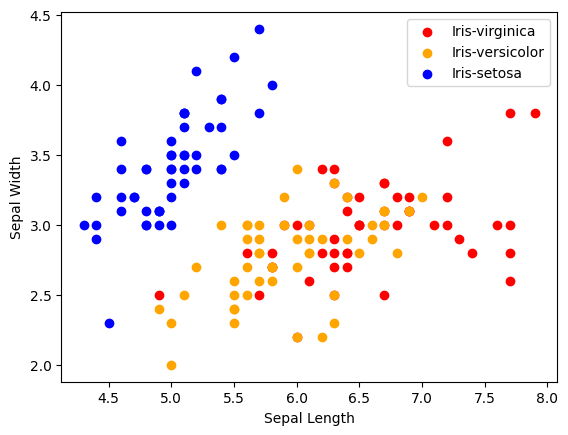

In [35]:
for i in range(3):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['SepalLengthCm'], x['SepalWidthCm'], c = colors[i], label=species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()

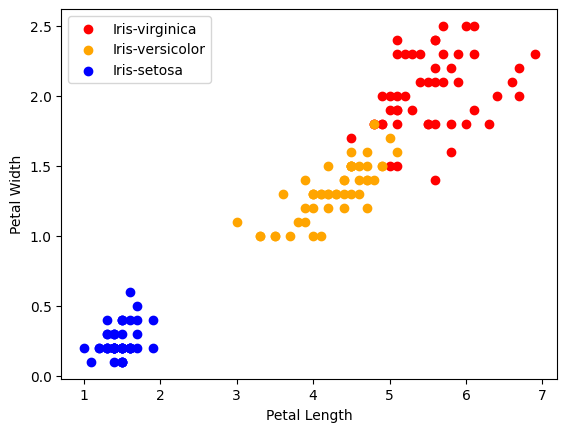

In [36]:
for i in range(3):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['PetalLengthCm'], x['PetalWidthCm'], c = colors[i], label=species[i])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()

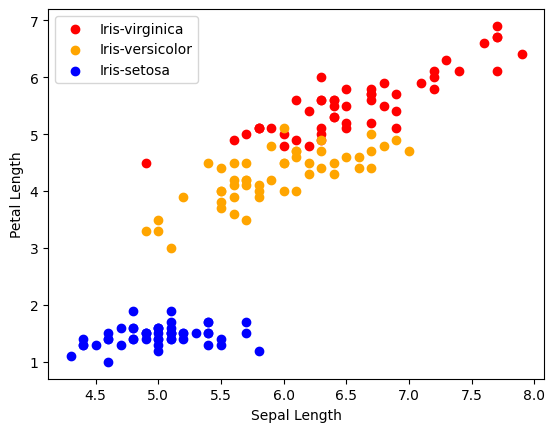

In [37]:
for i in range(3):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['SepalLengthCm'], x['PetalLengthCm'], c = colors[i], label=species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()

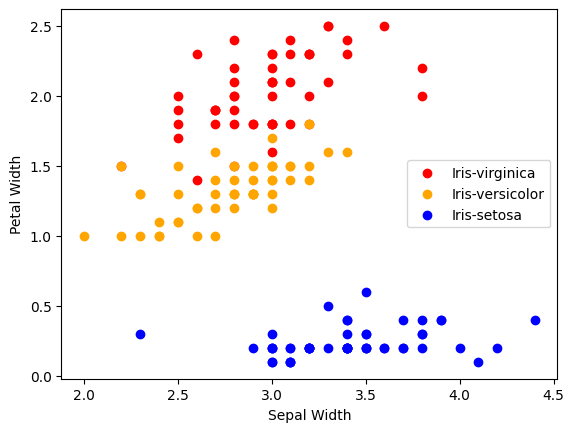

In [38]:
for i in range(3):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['SepalWidthCm'], x['PetalWidthCm'], c = colors[i], label=species[i])
plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.legend()

## <u> Coorelation Matrix </u>

A correlation matrix is a table showing correlation coefficients between variables. Each cell in the table shows the correlation between two variables. The value is in the range of -1 to 1. If two varibles have high correlation, we can neglect one variable from those two.

In [39]:
# Identify non-numeric columns
non_numeric_columns = df.select_dtypes(exclude=['number']).columns

# Exclude non-numeric columns and calculate correlation
numeric_df = df.drop(columns=non_numeric_columns)
correlation_matrix = numeric_df.corr()
correlation_matrix


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


<Axes: >

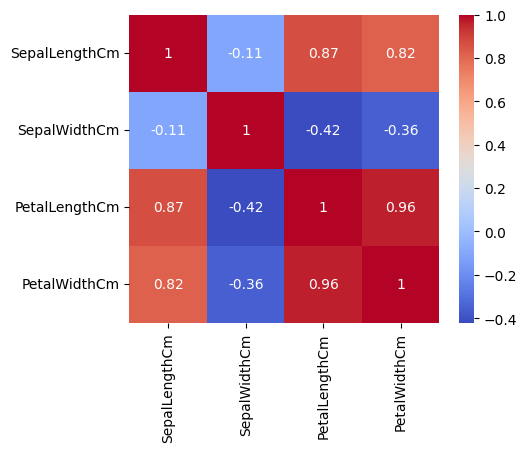

In [40]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(correlation_matrix, annot=True, ax=ax, cmap = 'coolwarm')

## <u> Label Encoder </u>

In machine learning, we usually deal with datasets which contains multiple labels in one or more than one columns. These labels can be in the form of words or numbers. Label Encoding refers to converting the labels into numeric form so as to convert it into the machine-readable form

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [42]:
df['Species'] = le.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# <b> Model Training <b>

In [43]:
from sklearn.model_selection import train_test_split
# train - 70
# test - 30
X = df.drop(columns=['Species'])
Y = df['Species']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30)

### <b> logistic regression <b>

In [44]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [45]:
# model training
model.fit(x_train, y_train)

LogisticRegression()

In [46]:
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
print('Accuracy: ',accuracy_score(y_test,y_pred)*100)

Accuracy:  97.77777777777777


In [47]:
# print metric to get performance
print("Accuracy: ",model.score(x_test, y_test) * 100)

Accuracy:  97.77777777777777


### <b> knn - k-nearest neighbours </b>

In [48]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

In [49]:
model.fit(x_train, y_train)

KNeighborsClassifier()

In [50]:
# print metric to get performance
print("Accuracy: ",model.score(x_test, y_test) * 100)

Accuracy:  97.77777777777777


### <b> Decision tree </b>


In [51]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [52]:
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [53]:
print("Accuracy: ",model.score(x_test, y_test) * 100)

Accuracy:  93.33333333333333
